In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

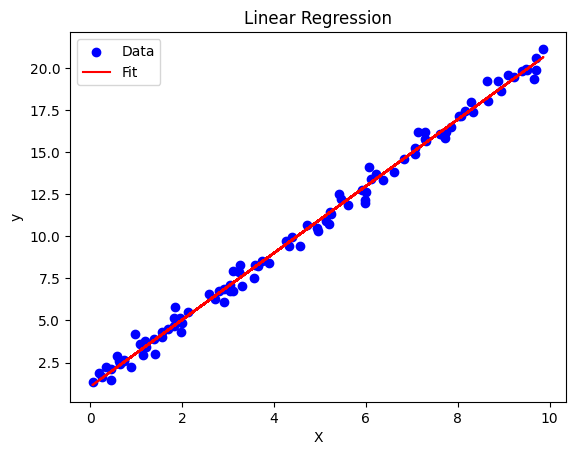

Weight: 1.98, Bias: 1.06


In [ ]:
# Generate synthetic data
np.random.seed(42)
X = np.random.rand(100, 1) * 10  # 100 samples, X in [0, 10]
y = 2 * X + 1 + np.random.randn(100, 1) * 0.5  # y = 2x + 1 + noise

# Linear regression functions
def predict(X, weight, bias):
    return np.dot(X, weight) + bias

def train(X, y, learning_rate=0.01, iterations=1000):
    n_samples, n_features = X.shape
    weight = np.zeros(n_features)
    bias = 0

    # Gradient descent
    for _ in range(iterations):
        y_pred1 = predict(X, weight, bias)
        dw = (1 / n_samples) * np.dot(X.T, (y_pred1 - y))  
        db = (1 / n_samples) * np.sum(y_pred1 - y)        
        weight -= learning_rate * dw
        bias -= learning_rate * db
    
    return weight, bias

# Train model
weight, bias = train(X, y.ravel())

# Predict
y_pred1 = predict(X, weight, bias)

# Plot data and regression line
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, y_pred1, color='red', label='Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression')
plt.legend()
plt.show()

# Print parameters
print(f"Weight: {weight[0]:.2f}, Bias: {bias:.2f}")

In [32]:
# evaluate model
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y, y_pred1)
r2 = r2_score(y, y_pred1)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

Mean Squared Error: 0.20232339446397765
R^2 Score: 0.9941264619388721


In [27]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate 100 samples
n_samples = 100
X = np.random.rand(n_samples, 1) * 10  # X values in range [0, 10]
noise = np.random.randn(n_samples, 1) * 0.5  # Gaussian noise with standard deviation 0.5
y = 2 * X + 1 + noise  # Linear relationship: y = 2x + 1 + noise

In [28]:
# train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Mean Squared Error: 0.16342487842925071
R^2 Score: 0.9957338020477439


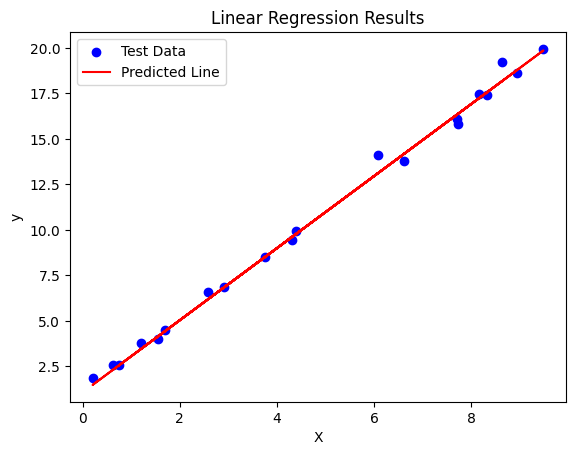

In [29]:
# fit linear regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
# make predictions
y_pred = model.predict(X_test)
# evaluate model
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

# plot results
plt.scatter(X_test, y_test, color='blue', label='Test Data')
plt.plot(X_test, y_pred, color='red', label='Predicted Line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Results')
plt.legend()
plt.show()

MSE Comparison

Scikit-learn MSE: 0.16
Scratch MSE: 0.20
Difference: The scikit-learn model has a lower MSE, indicating better predictive performance compared to the scratch implementation.

Analysis

Performance Difference:

The scikit-learn model (MSE = 0.16) fits the data slightly better than the scratch model (MSE = 0.20). A lower MSE means the predictions are closer to the actual values on average.
The difference (0.04) is relatively small, suggesting that your scratch implementation is performing reasonably well but not as optimally as scikit-learn's.